In [2]:
import numpy as np
np.bool = np.bool_ 
import pandas as pd
import os
from tqdm import tqdm

import mxnet as mx
from mxnet import gluon
from mxnet import autograd
from mxnet import image

import sys
sys.path.append('resuneta/src')
sys.path.append('decode/FracTAL_ResUNet/models/semanticsegmentation')
sys.path.append('decode/FracTAL_ResUNet/nn/loss')
sys.path.append('autogeobound/MXNet-ResUNeta/')

from bound_dist import get_distance, get_boundary
from FracTAL_ResUNet import FracTAL_ResUNet_cmtsk
#from ftnmt_loss import ftnmt_loss
from datasets import *

from sklearn.metrics import matthews_corrcoef

import random

import rasterio
from rasterio.enums import ColorInterp
from rasterio.features import shapes
from scipy import ndimage

import matplotlib.pyplot as plt
%matplotlib inline

import higra as hg
import torch
import pickle

import itertools

import imageio.v3 as imageio
from skimage.color import label2rgb
import cv2
from skimage.segmentation import mark_boundaries
from skimage.segmentation import find_boundaries

from shapely.geometry import shape
import shapely
from shapely import Polygon, orient_polygons
from shapely.plotting import plot_polygon

import ast
import pyproj

In [2]:
n_filters = 32
depth = 6
n_classes = 1
ctx = mx.gpu(2)
model = FracTAL_ResUNet_cmtsk(nfilters_init=n_filters, depth=depth, NClasses=n_classes)
model.load_parameters('experiments/8m-resolution/US/fractal-resunet_NAIP_nfilter-32_depth-6_bs-80_lr-0.001/model-20epoch.params', ctx=ctx)

def predict_boundaries_512(image):
    bound = np.zeros((512, 512))
    count = np.zeros((512, 512))
    topleft_indices = list(itertools.product([0, 128, 256], [0, 128, 256]))
    for topleft_index in topleft_indices:
        x1, x2, y1, y2 = topleft_index[0], topleft_index[0]+256, topleft_index[1], topleft_index[1]+256
        image_crop = mx.nd.array(image[:, :, x1:x2, y1:y2])
        _, bound_crop, _ = model(image_crop.as_in_context(ctx))
        bound[x1:x2, y1:y2] += bound_crop[0][0].asnumpy()
        count[x1:x2, y1:y2] += np.ones((256, 256))
    bound /= count
    return bound

depth:= 0, nfilters: 32, nheads::8, widths::1
depth:= 1, nfilters: 64, nheads::16, widths::1
depth:= 2, nfilters: 128, nheads::32, widths::1
depth:= 3, nfilters: 256, nheads::64, widths::1
depth:= 4, nfilters: 512, nheads::128, widths::1
depth:= 5, nfilters: 1024, nheads::256, widths::1
depth:= 6, nfilters: 512, nheads::256, widths::1
depth:= 7, nfilters: 256, nheads::128, widths::1
depth:= 8, nfilters: 128, nheads::64, widths::1
depth:= 9, nfilters: 64, nheads::32, widths::1
depth:= 10, nfilters: 32, nheads::16, widths::1


[01:06:27] /work/mxnet/src/base.cc:79: cuDNN lib mismatch: linked-against version 8200 != compiled-against version 8500.  Set MXNET_CUDNN_LIB_CHECKING=0 to quiet this warning.


In [2]:
data = pd.read_csv('calibration_data/calibration_points_with_sampled_coords.csv')
labels = pd.read_csv('calibration_data/labels.csv')

def labelstudio_polygon_to_shapely_polygon(polygon):
    points = ast.literal_eval(polygon.replace('true', 'True'))[0]['points']
    coords = []
    for x, y in points:
        # https://labelstud.io/guide/export#Units-of-image-annotations
        pixel_x = x / 100.0 * 1536
        pixel_y = y / 100.0 * 1536
        coords.append([pixel_x, pixel_y])
    shapely_polygon = Polygon(coords)
    shapely_polygon = orient_polygons(shapely_polygon)
    return shapely_polygon

labels = labels[labels['classification'] != 'Non-field']
labels['image_filename'] = labels['labelstudio_filename'].apply(lambda x: f'calibration_data/images/{x[-8:-4]}.tif')
labels['true_field'] = labels['polygon'].apply(labelstudio_polygon_to_shapely_polygon)
labels.drop(columns=['classification', 'labelstudio_filename', 'polygon'], inplace=True)

results_table = pd.merge(labels, data, on='image_filename')[["image_filename", "sampled_coords", "true_field"]]
results_table['sampled_coords'] = results_table['sampled_coords'].apply(lambda x: [int(i) for i in x[1:-1].strip().split()])

results_table['true_field_num_pixels'] = results_table['true_field'].apply(lambda x: x.area)

In [3]:
results_table

,image_filename,sampled_coords,true_field,true_field_num_pixels
0,calibration_data/images/0003.tif,"[700, 677]","POLYGON ((668.1259034202352 694.1624727974021,...",607.806408
1,calibration_data/images/0004.tif,"[931, 632]","POLYGON ((517.5493016963111 852.19728105948, 9...",41928.429748
2,calibration_data/images/0005.tif,"[1015, 852]",POLYGON ((815.2852938350318 1001.5684712883981...,10140.867473
3,calibration_data/images/0006.tif,"[890, 1003]","POLYGON ((961.356181220187 837.7715917179488, ...",2120.064493
4,calibration_data/images/0007.tif,"[989, 1018]","POLYGON ((996.2929602427675 962.1288318865411,...",1377.438816
...,...,...,...,...
453,calibration_data/images/0373.tif,"[808, 906]","POLYGON ((895.1783228461454 800.271873982023, ...",417.879846
454,calibration_data/images/0117.tif,"[626, 1017]","POLYGON ((986.0852342370151 611.1437019860286,...",1068.182388
455,calibration_data/images/0422.tif,"[777, 872]","POLYGON ((816.2853699178564 716.0079428906608,...",18442.432196
456,calibration_data/images/0424.tif,"[927, 629]","POLYGON ((605.8451482647395 946.937039567357, ...",6198.645438


0.013100436681222707


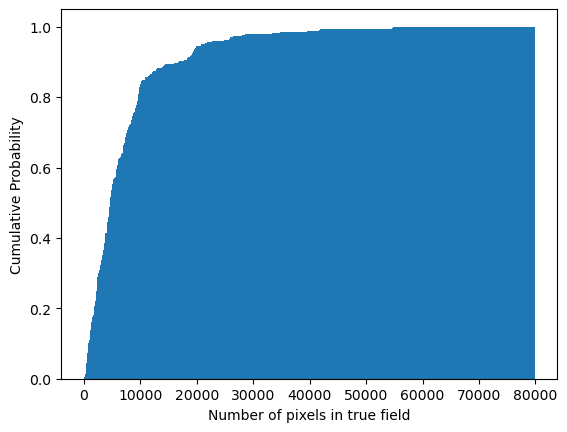

In [5]:
print(len(results_table[results_table["true_field_num_pixels"] < 300]) / len(results_table))

plt.hist(results_table["true_field_num_pixels"], bins=np.arange(0, 80000, 100), density=True, cumulative=True)
plt.xlabel("Number of pixels in true field")
plt.ylabel("Cumulative Probability")
plt.show()

In [6]:
calibration_lat_lons = pd.merge(results_table, data, on='image_filename')[['image_filename', '.geo']]
calibration_lat_lons['latitude'] = calibration_lat_lons['.geo'].apply(lambda x: ast.literal_eval(x)["coordinates"][1])
calibration_lat_lons['longitude'] = calibration_lat_lons['.geo'].apply(lambda x: ast.literal_eval(x)["coordinates"][0])
calibration_lat_lons.drop(columns=['.geo'], inplace=True)
calibration_lat_lons.to_csv('calibration_data/calibration_points_lat_lons.csv', index=False)

# Get IoUs for each value of T (watershed algorithm parameter)

In [6]:
image_filenames = results_table["image_filename"]
sampled_coords = results_table["sampled_coords"]
true_fields = results_table["true_field"]
n = len(true_fields)

T_values = np.concatenate([np.arange(0.001, 0.01, 0.001), np.arange(.01, 1, .01)])
graph = hg.get_8_adjacency_graph((512, 512))

pred_fields = []
IOUs = []
for i in tqdm(range(n)):
    image_filename = image_filenames[i]
    coord = sampled_coords[i]
    true_field = true_fields[i]
    
    image = imageio.imread(image_filename)
    image = np.moveaxis(image, -1, 0)[np.newaxis, :]
    topleft_indices = list(itertools.product([0, 512, 1024], [0, 512, 1024]))

    trees_list = []
    altitudes_list = []
    bbox_coords_list = []
    for topleft_index in topleft_indices:
        x1, x2, y1, y2 = topleft_index[0], topleft_index[0]+512, topleft_index[1], topleft_index[1]+512
        bound = predict_boundaries_512(image[:, :, x1:x2, y1:y2])
        edge_weights = hg.weight_graph(graph,bound,hg.WeightFunction.mean)
        tree, altitudes = hg.watershed_hierarchy_by_dynamics(graph, edge_weights)
        trees_list.append(tree)
        altitudes_list.append(altitudes)
        bbox_coords_list.append((x1, x2, y1, y2))

    pred_fields_i = []
    IOUs_i = []
    for T in T_values:
        pred_segmentation = np.zeros((1536, 1536))
        for j in range(len(topleft_indices)):
            x1, x2, y1, y2 = bbox_coords_list[j]
            tree = trees_list[j]
            altitudes = altitudes_list[j]
            pred_segmentation_j = hg.labelisation_horizontal_cut_from_threshold(tree,altitudes,threshold=T).astype(float) 
            binary_field_extent_j = find_boundaries(pred_segmentation_j)==0
            pred_segmentation[x1:x2, y1:y2] = binary_field_extent_j
        ndimage.label(pred_segmentation, output=pred_segmentation)
        ndimage.grey_dilation(pred_segmentation, size=(3, 3), output=pred_segmentation)

        if pred_segmentation[coord[0], coord[1]] == 0:
            pred_field = np.nan
            IOU = 0
        else:
            pred_field_mask = (pred_segmentation==pred_segmentation[coord[0], coord[1]]).astype(np.uint8)
            if np.sum(pred_field_mask) < 300: # the predicted field will be removed if it is too small
                pred_field = np.nan
                IOU = 0
            else:
                for s, v in shapes(source=pred_field_mask, mask=pred_field_mask):
                    pred_field = shape(s)
                    break
                IOU = true_field.intersection(pred_field).area / true_field.union(pred_field).area
        pred_fields_i.append(pred_field)
        IOUs_i.append(IOU)

    pred_fields.append(pred_fields_i)
    IOUs.append(IOUs_i)

results_table['pred_fields'] = pred_fields 
results_table['IOUs_nonsimplified'] = IOUs

[01:29:49] /work/mxnet/src/operator/nn/./cudnn/./cudnn_algoreg-inl.h:96: Running performance tests to find the best convolution algorithm, this can take a while... (set the environment variable MXNET_CUDNN_AUTOTUNE_DEFAULT to 0 to disable)
[01:29:52] /work/mxnet/src/operator/nn/./cudnn/cudnn_pooling-inl.h:374: 0D pooling is not supported by cudnn, MXNet 0D pooling is applied.
[01:29:54] /work/mxnet/src/operator/nn/./cudnn/./cudnn_algoreg-inl.h:96: Running performance tests to find the best convolution algorithm, this can take a while... (set the environment variable MXNET_CUDNN_AUTOTUNE_DEFAULT to 0 to disable)
100%|██████████| 458/458 [3:04:46<00:00, 24.21s/it]  


In [7]:
results_table

,image_filename,sampled_coords,true_field,true_field_num_pixels,pred_fields,IOUs_nonsimplified
0,calibration_data/images/0003.tif,"[700, 677]","POLYGON ((668.1259034202352 694.1624727974021,...",607.806408,"[POLYGON ((667 692, 667 705, 668 705, 668 711,...","[0.6326063923754837, 0.6326063923754837, 0.632..."
1,calibration_data/images/0004.tif,"[931, 632]","POLYGON ((517.5493016963111 852.19728105948, 9...",41928.429748,"[POLYGON ((615 915, 615 930, 614 930, 614 932,...","[0.012759838687365264, 0.05282811718226928, 0...."
2,calibration_data/images/0005.tif,"[1015, 852]",POLYGON ((815.2852938350318 1001.5684712883981...,10140.867473,"[POLYGON ((819 1004, 819 1005, 818 1005, 818 1...","[0.6561978672816751, 0.9153996360461754, 0.926..."
3,calibration_data/images/0006.tif,"[890, 1003]","POLYGON ((961.356181220187 837.7715917179488, ...",2120.064493,"[nan, POLYGON ((1003 861, 1003 862, 1002 862, ...","[0, 0.22861293721477882, 0.9166868603126487, 0..."
4,calibration_data/images/0007.tif,"[989, 1018]","POLYGON ((996.2929602427675 962.1288318865411,...",1377.438816,"[nan, POLYGON ((1004 982, 1004 983, 1002 983, ...","[0, 0.5081912850497922, 0.822932368373119, 0.8..."
...,...,...,...,...,...,...
453,calibration_data/images/0373.tif,"[808, 906]","POLYGON ((895.1783228461454 800.271873982023, ...",417.879846,"[nan, nan, nan, nan, nan, nan, nan, POLYGON ((...","[0, 0, 0, 0, 0, 0, 0, 0.7810838246266931, 0.78..."
454,calibration_data/images/0117.tif,"[626, 1017]","POLYGON ((986.0852342370151 611.1437019860286,...",1068.182388,"[nan, nan, nan, nan, nan, POLYGON ((1023 601, ...","[0, 0, 0, 0, 0, 0.28105081144572025, 0.2810508..."
455,calibration_data/images/0422.tif,"[777, 872]","POLYGON ((816.2853699178564 716.0079428906608,...",18442.432196,"[nan, POLYGON ((887 767, 887 768, 875 768, 875...","[0, 0.026460718131087253, 0.03515797095725037,..."
456,calibration_data/images/0424.tif,"[927, 629]","POLYGON ((605.8451482647395 946.937039567357, ...",6198.645438,"[nan, POLYGON ((605 925, 605 939, 604 939, 604...","[0, 0.10577518344608897, 0.10577518344608897, ..."


In [8]:
file = open('calibration_data/conformal_results.pkl', 'wb')
pickle.dump(results_table, file)
file.close()

# Simplify polygons and recompute IoUs

In [178]:
file = open('calibration_data/conformal_results.pkl', 'rb')
results_table = pickle.load(file)
file.close()

In [179]:
data = pd.read_csv('calibration_data/calibration_points_with_sampled_coords.csv')

In [180]:
data = data[["image_filename", ".geo"]]
results_table = pd.merge(results_table, data, on=["image_filename"])
results_table["lon_lat"] = results_table[".geo"].apply(lambda x: ast.literal_eval(x)["coordinates"])
results_table = results_table.drop(columns=".geo")

In [181]:
results_table

,image_filename,sampled_coords,true_field,true_field_num_pixels,pred_fields,IOUs_nonsimplified,lon_lat
0,calibration_data/images/0003.tif,"[700, 677]","POLYGON ((668.1259034202352 694.1624727974021,...",607.806408,"[POLYGON ((667 692, 667 705, 668 705, 668 711,...","[0.6326063923754837, 0.6326063923754837, 0.632...","[-88.80564172629936, 42.98497164893813]"
1,calibration_data/images/0004.tif,"[931, 632]","POLYGON ((517.5493016963111 852.19728105948, 9...",41928.429748,"[POLYGON ((615 915, 615 930, 614 930, 614 932,...","[0.012759838687365264, 0.05282811718226928, 0....","[-100.94354666703381, 45.871169396791515]"
2,calibration_data/images/0005.tif,"[1015, 852]",POLYGON ((815.2852938350318 1001.5684712883981...,10140.867473,"[POLYGON ((819 1004, 819 1005, 818 1005, 818 1...","[0.6561978672816751, 0.9153996360461754, 0.926...","[-97.04459342882076, 47.50452919446663]"
3,calibration_data/images/0006.tif,"[890, 1003]","POLYGON ((961.356181220187 837.7715917179488, ...",2120.064493,"[nan, POLYGON ((1003 861, 1003 862, 1002 862, ...","[0, 0.22861293721477882, 0.9166868603126487, 0...","[-95.85329553228112, 41.70342154707673]"
4,calibration_data/images/0007.tif,"[989, 1018]","POLYGON ((996.2929602427675 962.1288318865411,...",1377.438816,"[nan, POLYGON ((1004 982, 1004 983, 1002 983, ...","[0, 0.5081912850497922, 0.822932368373119, 0.8...","[-89.18533864010134, 34.733672695599736]"
...,...,...,...,...,...,...,...
453,calibration_data/images/0373.tif,"[808, 906]","POLYGON ((895.1783228461454 800.271873982023, ...",417.879846,"[nan, nan, nan, nan, nan, nan, nan, POLYGON ((...","[0, 0, 0, 0, 0, 0, 0, 0.7810838246266931, 0.78...","[-78.45703134707902, 35.14200595636694]"
454,calibration_data/images/0117.tif,"[626, 1017]","POLYGON ((986.0852342370151 611.1437019860286,...",1068.182388,"[nan, nan, nan, nan, nan, POLYGON ((1023 601, ...","[0, 0, 0, 0, 0, 0.28105081144572025, 0.2810508...","[-121.78320449042472, 36.747844182340195]"
455,calibration_data/images/0422.tif,"[777, 872]","POLYGON ((816.2853699178564 716.0079428906608,...",18442.432196,"[nan, POLYGON ((887 767, 887 768, 875 768, 875...","[0, 0.026460718131087253, 0.03515797095725037,...","[-102.93238600068966, 48.99172411871084]"
456,calibration_data/images/0424.tif,"[927, 629]","POLYGON ((605.8451482647395 946.937039567357, ...",6198.645438,"[nan, POLYGON ((605 925, 605 939, 604 939, 604...","[0, 0.10577518344608897, 0.10577518344608897, ...","[-103.17784167727763, 48.96845207031291]"


In [182]:
image_filenames = results_table["image_filename"]
true_fields = results_table["true_field"]
pred_fields = results_table["pred_fields"]
lon_lats = results_table["lon_lat"]
n = len(true_fields)

IOUs = []
true_fields_epsg5070 = []
pred_fields_epsg5070 = []
pred_fields_epsg5070_final = []

lon_lat_transform = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:5070", always_xy=True).transform
for i in tqdm(range(n)):
    image_filename = image_filenames[i]
    src = rasterio.open(image_filename)
    transform = src.transform
    
    true_field_i = true_fields[i]
    true_field_i = shapely.get_coordinates(true_field_i).tolist()
    true_field_i = Polygon([transform * (x, y) for x, y in true_field_i])
    true_fields_epsg5070.append(true_field_i)
    
    pred_fields_i = pred_fields[i]

    lon_lat_i = lon_lats[i]
    lon_lat_i = shapely.Point(lon_lat_transform(lon_lat_i[0], lon_lat_i[1]))

    IOUs_i = []
    pred_fields_epsg5070_i = []
    pred_fields_epsg5070_final_i = []
    for pred_field in pred_fields_i:
        if pd.isnull(pred_field):
            pred_epsg5070 = np.nan
            pred_epsg5070_final = np.nan
            IOU = 0
        else:
            pred_field = shapely.get_coordinates(pred_field).tolist()
            pred_epsg5070 = Polygon([transform * (x, y) for x, y in pred_field]).buffer(0)
            pred_epsg5070_final = pred_epsg5070.simplify(tolerance=8, preserve_topology=True).buffer(-8)
            IOU = true_field_i.intersection(pred_epsg5070_final).area / true_field_i.union(pred_epsg5070_final).area
            # make sure the eroded simplified shape still contains the sampled lon-lat coordinate
            if not shapely.contains(pred_epsg5070_final, lon_lat_i): 
                pred_epsg5070 = np.nan
                pred_epsg5070_final = np.nan
                IOU = 0
        pred_fields_epsg5070_i.append(pred_epsg5070)
        pred_fields_epsg5070_final_i.append(pred_epsg5070_final)
        IOUs_i.append(IOU)

    pred_fields_epsg5070.append(pred_fields_epsg5070_i)
    pred_fields_epsg5070_final.append(pred_fields_epsg5070_final_i)
    IOUs.append(IOUs_i)

results_table["true_field_epsg5070"] = true_fields_epsg5070
results_table["pred_fields_epsg5070"] = pred_fields_epsg5070
results_table["pred_fields_epsg5070_final"] = pred_fields_epsg5070_final
results_table["IOUs_final"] = IOUs

100%|██████████| 458/458 [02:12<00:00,  3.46it/s]


In [183]:
file = open('calibration_data/conformal_results_final.pkl', 'wb')
pickle.dump(results_table, file)
file.close()

# Randomly split data into calibration and test sets

In [184]:
file = open('calibration_data/conformal_results_final.pkl', 'rb')
results_table = pickle.load(file)
file.close()

In [185]:
results_table[['image_filename', 'true_field_epsg5070']].to_csv('calibration_data/calibration_true_fields.csv', index=False)

In [186]:
results_table = results_table[results_table['true_field_num_pixels'] >= 300].reset_index()
print(len(results_table))

452


In [187]:
results_table['data_split'] = 'calibration'
results_table.loc[results_table.sample(n=150, random_state=0).index, 'data_split'] = 'test'

In [188]:
file = open('calibration_data/conformal_results_final.pkl', 'wb')
pickle.dump(results_table, file)
file.close()

# Analyze calibration results

In [3]:
file = open('calibration_data/conformal_results_final.pkl', 'rb')
results_table = pickle.load(file)
file.close()

results_table = results_table[results_table['data_split']=='calibration'].reset_index()

In [4]:
T_values = np.concatenate([np.arange(0.001, 0.01, 0.001), np.arange(.01, 1, .01)])
IOU_threshold = 0.8
def compute_Ts_with_high_IOU(IOUs):
    indices_with_high_IOU = np.argwhere(np.array(IOUs) > IOU_threshold)[:, 0]
    return T_values[indices_with_high_IOU]

results_table["max IOU"] = results_table["IOUs_final"].map(lambda x: np.max(x))
results_table["Ts with high IOU"] = results_table["IOUs_final"].map(compute_Ts_with_high_IOU)

In [5]:
results_table

,level_0,index,image_filename,sampled_coords,true_field,true_field_num_pixels,pred_fields,IOUs_nonsimplified,lon_lat,true_field_epsg5070,pred_fields_epsg5070,pred_fields_epsg5070_final,IOUs_final,data_split,max IOU,Ts with high IOU
0,0,0,calibration_data/images/0003.tif,"[700, 677]","POLYGON ((668.1259034202352 694.1624727974021,...",607.806408,"[POLYGON ((667 692, 667 705, 668 705, 668 711,...","[0.6326063923754837, 0.6326063923754837, 0.632...","[-88.80564172629936, 42.98497164893813]","POLYGON ((582881.0072273619 2243150.700217621,...","[POLYGON ((582872 2243168, 582904 2243168, 582...","[POLYGON ((582880 2243159.061879877, 582940.32...","[0.620800329390303, 0.620800329390303, 0.62080...",calibration,0.832600,"[0.03, 0.04, 0.05, 0.060000000000000005, 0.069..."
1,2,2,calibration_data/images/0005.tif,"[1015, 852]",POLYGON ((815.2852938350318 1001.5684712883981...,10140.867473,"[POLYGON ((819 1004, 819 1005, 818 1005, 818 1...","[0.6561978672816751, 0.9153996360461754, 0.926...","[-97.04459342882076, 47.50452919446663]",POLYGON ((-79493.71764931975 2724019.452229692...,"[POLYGON ((-79464 2724000, -79408 2724000, -79...","[POLYGON ((-79459.05572809 2723992, -79409.888...","[0.6230637635227416, 0.9038516894538117, 0.920...",calibration,0.920964,"[0.002, 0.003]"
2,3,3,calibration_data/images/0006.tif,"[890, 1003]","POLYGON ((961.356181220187 837.7715917179488, ...",2120.064493,"[nan, POLYGON ((1003 861, 1003 862, 1002 862, ...","[0, 0.22861293721477882, 0.9166868603126487, 0...","[-95.85329553228112, 41.70342154707673]",POLYGON ((11786.849449761496 2078161.827266256...,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.9479728...",calibration,0.947973,"[0.04, 0.05, 0.060000000000000005, 0.069999999..."
3,9,10,calibration_data/images/0013.tif,"[875, 793]","POLYGON ((799.0018279428222 840.0841160866152,...",767.032093,"[POLYGON ((789 854, 789 855, 781 855, 781 856,...","[0.5032803154727739, 0.7198538187456837, 0.772...","[-76.8053580213774, 42.977270781418824]",POLYGON ((1546488.0146235425 2377151.327071307...,"[POLYGON ((1546408 2377040, 1546488 2377040, 1...","[POLYGON ((1546408.878177829 2377032, 1546485....","[0.472048406535318, 0.7586509652962256, 0.8473...",calibration,0.849714,"[0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.0..."
4,11,12,calibration_data/images/0015.tif,"[826, 976]","POLYGON ((959.4742572349473 798.9230017621289,...",1133.532066,"[POLYGON ((972 791, 972 792, 969 792, 969 793,...","[0.6809563887179975, 0.6788960355492422, 0.678...","[-88.7538581857657, 37.43407753896024]","POLYGON ((634363.7940578796 1623816.615985903,...","[POLYGON ((634464 1623880, 634488 1623880, 634...",[POLYGON ((634464.8675377946 1623871.668061219...,"[0.7236590465919459, 0.7201425442027812, 0.720...",calibration,0.880961,"[0.008, 0.009000000000000001, 0.01, 0.02, 0.03..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,443,447,calibration_data/images/0498.tif,"[786, 907]","POLYGON ((888.9127595141089 751.1733746079583,...",2501.138439,"[POLYGON ((908 781, 908 782, 903 782, 903 783,...","[0.45094672024877563, 0.48216135136573157, 0.4...","[-96.69773333517637, 45.9328922735733]",POLYGON ((-54328.69792388713 2549894.613003136...,"[POLYGON ((-54176 2549656, -54152 2549656, -54...","[POLYGON ((-54216 2549633.5826271493, -54154.0...","[0.4334370203558518, 0.4655950632889528, 0.465...",calibration,0.753906,[]
298,444,448,calibration_data/images/0499.tif,"[704, 980]","POLYGON ((941.5318751395955 704.6358229412394,...",3849.876581,"[POLYGON ((1022 689, 1022 690, 1020 690, 1020 ...","[0.7118949485365447, 0.7731541013222474, 0.707...","[-91.4219835966003, 29.822409877132337]","POLYGON ((441708.2550011168 760314.91341647, 4...","[POLYGON ((442352 760440, 442376 760440, 44237...","[POLYGON ((442355.313708499 760432, 442371.718...","[0.7008922645173836, 0.7732795518812333, 0.727...",calibration,0.842464,"[0.004, 0.005, 0.006, 0.007, 0.0

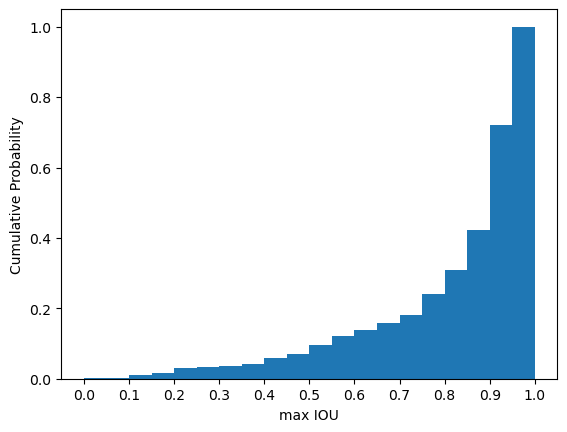

In [6]:
plt.hist(results_table["max IOU"], bins=np.arange(0, 1.01, .05), density=True, cumulative=True)
plt.xlabel("max IOU")
plt.ylabel("Cumulative Probability")
plt.xticks(np.arange(0, 1.01, 0.1))
plt.show()

In [7]:
len(results_table[results_table["max IOU"] > 0.6])/len(results_table)

0.8774834437086093

In [8]:
len(results_table[results_table["max IOU"] > 0.7])/len(results_table)

0.8410596026490066

In [9]:
len(results_table[results_table["max IOU"] > 0.8])/len(results_table)

0.7582781456953642

In [10]:
len(results_table[results_table["max IOU"] > 0.9])/len(results_table)

0.5761589403973509

# Do conformal calibration (asymptotic version with greedy algorithm)

In [11]:
print(IOU_threshold)

0.8


In [12]:
alpha = .3

import itertools
import math
results_table_high_IOUs = results_table[results_table["max IOU"] > IOU_threshold]
p = 1 - len(results_table_high_IOUs) / len(results_table)
print(p)
if p > alpha:
    print("too uncertain")
else:
    IOUs = np.array([np.array(x) for x in results_table["IOUs_final"]])
    IOUs_high = (IOUs>IOU_threshold).astype(int)
    T_confidence_set = []
    num_calibration_pixels_covered = 0
    num_calibration_pixels_target = (1-alpha)*len(results_table)
    while num_calibration_pixels_covered < num_calibration_pixels_target:
        coverage_by_T = IOUs_high.sum(axis=0)
        best_T = np.argmax(coverage_by_T)
        calibration_pixels_covered = np.argwhere(IOUs_high[:, best_T]==1)
        IOUs_high = np.delete(IOUs_high, calibration_pixels_covered, axis=0)
        
        T_confidence_set.append(best_T)
        num_calibration_pixels_covered += np.max(coverage_by_T)

        print(T_values[best_T])
        print("Percent of calibration pixels covered so far:", num_calibration_pixels_covered/len(results_table))
    
    T_confidence_set = T_values[np.sort(T_confidence_set)]
    print("Greedy algorithm output:", T_confidence_set)

0.24172185430463577
0.08
Percent of calibration pixels covered so far: 0.4900662251655629
0.005
Percent of calibration pixels covered so far: 0.6125827814569537
0.2
Percent of calibration pixels covered so far: 0.6589403973509934
0.02
Percent of calibration pixels covered so far: 0.6920529801324503
0.002
Percent of calibration pixels covered so far: 0.7086092715231788
Greedy algorithm output: [0.002 0.005 0.02  0.08  0.2  ]


# Do conformal calibration (finite sample version)

In [13]:
print(IOU_threshold)

0.8


In [14]:
alpha = .3

In [15]:
results_table['calibration_step'] = 'step2'
results_table.loc[results_table.sample(n=151, random_state=0).index, 'calibration_step'] = 'step1'

In [16]:
results_table_1 = results_table[results_table['calibration_step'] == 'step1']
results_table_2 = results_table[results_table['calibration_step'] == 'step2']

In [17]:
print(len(results_table_1))
print(len(results_table_2))

151
151


In [18]:
len(results_table_1[results_table_1["max IOU"] > 0.8])/len(results_table_1)

0.7019867549668874

In [19]:
len(results_table_2[results_table_2["max IOU"] > 0.8])/len(results_table_2)

0.8145695364238411

Step 1

In [20]:
import itertools
import math

T_ordering_indices = []
IOUs = np.array([np.array(x) for x in results_table_1["IOUs_final"]])
IOUs_high = (IOUs>IOU_threshold).astype(int)
while True:
    coverage_by_T = IOUs_high.sum(axis=0)
    if np.max(coverage_by_T) == 0:
        break
    else:
        best_T = np.argmax(coverage_by_T)
        calibration_pixels_covered = np.argwhere(IOUs_high[:, best_T]==1)
        IOUs_high = np.delete(IOUs_high, calibration_pixels_covered, axis=0)
        T_ordering_indices.append(best_T)

T_ordering = T_values[T_ordering_indices]
print("T indices in ranked order from highest to lowest priority:", T_ordering_indices)
print("T in ranked order from highest to lowest priority:", T_ordering)

T indices in ranked order from highest to lowest priority: [10, 28, 4, 15, 42, 1, 5]
T in ranked order from highest to lowest priority: [0.02  0.2   0.005 0.07  0.34  0.002 0.006]


Step 2

In [21]:
import itertools
def compute_pair_to_iou_dict(polygons):
    indices = np.arange(len(polygons))
    pairs = itertools.combinations(indices, 2)
    pair_to_iou = {}
    for pair in pairs:
        i, j = pair
        if pd.isnull(polygons[i]) or pd.isnull(polygons[j]):
            pair_to_iou[tuple(pair)] = 0
        else:
            pair_to_iou[tuple(pair)] = polygons[i].intersection(polygons[j]).area / polygons[i].union(polygons[j]).area
    return pair_to_iou

pair_to_iou_dicts = []
for index, row in tqdm(results_table_2.iterrows(), total=results_table_2.shape[0]):
    pred_shapes_coord = np.array(row["pred_fields"])[T_ordering_indices[:8]]
    pair_to_iou_dicts.append(compute_pair_to_iou_dict(pred_shapes_coord))

results_table_2["Pred Mask Pair to IOUs"] = pair_to_iou_dicts

100%|██████████| 151/151 [00:01<00:00, 80.55it/s]
/tmp/ipykernel_2321031/92939971.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_table_2["Pred Mask Pair to IOUs"] = pair_to_iou_dicts


In [22]:
def remove_duplicate_masks_finite_sample(indices, pair_to_iou, iou_threshold):
    if len(indices) == 1:
        return indices
    else:
        indices_to_keep = remove_duplicate_masks_finite_sample(indices[:-1], pair_to_iou, iou_threshold)
        for index in indices[:-1]:
            IOU = pair_to_iou[(index, indices[-1])]
            if IOU > iou_threshold:
                return indices_to_keep
        indices_to_keep.append(indices[-1])
        return indices_to_keep

In [23]:
IOU_threshold_duplicate_mask = 0.95
n2 = len(results_table_2)
pair_to_iou_dicts = np.array(results_table_2["Pred Mask Pair to IOUs"])
IOUs = np.array([np.array(x) for x in results_table_2["IOUs_final"]])
IOUs_high = (IOUs>IOU_threshold).astype(int)[:, T_ordering_indices]
target_risk = alpha - (1-alpha)/n2

for i in range(len(T_ordering_indices[:8])):
    num_points_covered = 0
    for j in range(n2):
        pair_to_iou = pair_to_iou_dicts[j]
        indices_to_keep = remove_duplicate_masks_finite_sample(list(np.arange(i+1)), pair_to_iou, IOU_threshold_duplicate_mask)
        if np.max(IOUs_high[j][indices_to_keep]) == 1:
            num_points_covered += 1
    risk = 1 - num_points_covered / n2 # fraction of points that have not been covered
    if risk <= target_risk:
        break

T_confidence_set_indices = T_ordering_indices[:i+1]
T_confidence_set = T_values[T_confidence_set_indices]

print("target risk:", target_risk)
print("final risk:", risk)
if risk > target_risk:
    print("alpha too small")
else:
    print("T confidence set indices:", T_confidence_set_indices)
    print("T confidence set:", T_confidence_set)

target risk: 0.295364238410596
final risk: 0.29139072847682124
T confidence set indices: [10, 28, 4, 15]
T confidence set: [0.02  0.2   0.005 0.07 ]


# Compute coverage on test set

In [24]:
file = open('calibration_data/conformal_results_final.pkl', 'rb')
results_table = pickle.load(file)
file.close()

results_table = results_table[results_table['data_split']=='test'].reset_index()
results_table["max IOU"] = results_table["IOUs_final"].map(lambda x: np.max(x))

In [25]:
len(results_table[results_table["max IOU"] > 0.8])/len(results_table)

0.72

In [26]:
pair_to_iou_dicts = []
for index, row in tqdm(results_table.iterrows(), total=results_table.shape[0]):
    pred_shapes_coord = np.array(row["pred_fields"])[T_confidence_set_indices]
    pair_to_iou_dicts.append(compute_pair_to_iou_dict(pred_shapes_coord))

results_table["Pred Mask Pair to IOUs"] = pair_to_iou_dicts

100%|██████████| 150/150 [00:00<00:00, 211.29it/s]


In [27]:
results_table["Mask Indices"] = results_table["Pred Mask Pair to IOUs"].apply(lambda x: remove_duplicate_masks_finite_sample(list(np.arange(len(T_confidence_set))), x, iou_threshold=IOU_threshold_duplicate_mask))
results_table["Mask Indices nan"] = results_table.apply(lambda x: np.argwhere(pd.isnull(np.array(x["pred_fields_epsg5070_final"])[T_confidence_set_indices])).flatten(), axis=1)
results_table["Final Mask Indices"] = results_table.apply(lambda x: list(set(x["Mask Indices"]) - set(x["Mask Indices nan"])), axis=1)
results_table["Final Mask Number"] = results_table["Final Mask Indices"].apply(lambda x: len(x))
results_table["Final Mask IOUs"] = results_table.apply(lambda x: np.array(x["IOUs_final"])[T_confidence_set_indices][x["Final Mask Indices"]], axis=1)
results_table["Final Mask max IOU"] = results_table["Final Mask IOUs"].map(lambda x: 0 if len(x)==0 else np.max(x))

In [28]:
results_table_high_IOUs = results_table[results_table["Final Mask max IOU"] > IOU_threshold]
coverage = len(results_table_high_IOUs) / len(results_table)
print("Coverage:", coverage)
print("mean maximum IOU of confidence set:", np.mean(results_table["Final Mask max IOU"]))
print("median maximum IOU of confidence set:", np.median(results_table["Final Mask max IOU"]))

Coverage: 0.6733333333333333
mean maximum IOU of confidence set: 0.7735254440254351
median maximum IOU of confidence set: 0.9071758949376307


Comparison to single best parameter baseline

In [29]:
IOUs = np.array([np.array(x) for x in results_table["IOUs_final"]])
IOUs_high = (IOUs>IOU_threshold).astype(int)
coverage_by_T = IOUs_high.sum(axis=0)
best_T = np.argwhere(T_values==0.08)[0][0] # this was the T value with the highest coverage on the calibration set 
print("Best T:", 0.08)
print("Coverage at best T:", coverage_by_T[best_T]/len(results_table))
print("mean IOU at best T:", np.mean(IOUs[:, best_T]))
print("median IOU at best T:", np.median(IOUs[:, best_T]))

Best T: 0.08
Coverage at best T: 0.49333333333333335
mean IOU at best T: 0.6506804242457921
median IOU at best T: 0.7922579379418495
